In [198]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

In [127]:
df = pd.read_csv('data/ai_job_market.csv')
print(df.head())
df.shape

   job_id                  job_title company_size company_industry    country  \
0       1                AI Engineer      Startup           Retail     Canada   
1       2  Machine Learning Engineer          MNC       Technology  Australia   
2       3  Machine Learning Engineer          MNC       Technology    Germany   
3       4           Business Analyst      Startup       Healthcare    Germany   
4       5             Data Scientist          MNC       Healthcare    Germany   

  remote_type experience_level  years_experience education_level  \
0      Remote           Senior                 2          Master   
1      Hybrid              Mid                 0        Bachelor   
2      Onsite              Mid                14          Master   
3      Remote              Mid                 9          Master   
4      Hybrid              Mid                 5          Master   

   skills_python  skills_sql  skills_ml  skills_deep_learning  skills_cloud  \
0              0         

(10345, 19)

**Classifying into categorical and numerical features**

In [78]:
categorical_features = [feature for feature in df.columns if df[feature].dtype!=int]
numerical_features = [feature for feature in df.columns if df[feature].dtype==int and feature!='job_id'] #dropping the job id to prevent the noise  
print(f'The categorical features are: {categorical_features}')
print(f'The numerical features are: {numerical_features}')

The categorical features are: ['job_title', 'company_size', 'company_industry', 'country', 'remote_type', 'experience_level', 'education_level', 'hiring_urgency']
The numerical features are: ['years_experience', 'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month', 'job_posting_year', 'job_openings']


**Classifying into nominal and ordinal features**

In [79]:
nominal_categorical_features = ['job_title','company_industry','country','remote_type','company_size']  #has no order within them
ordinal_categorical_features = ['experience_level','education_level','hiring_urgency']  #has orders within them


**One_hot encoding for nominal categorical features**

In [80]:
X_nominal_encoded = pd.get_dummies(data=df[nominal_categorical_features],columns=nominal_categorical_features,drop_first=True,dtype=int)
X_nominal_encoded


,job_title_Business Analyst,job_title_Data Analyst,job_title_Data Engineer,job_title_Data Scientist,job_title_Machine Learning Engineer,company_industry_Education,company_industry_Finance,company_industry_Healthcare,company_industry_Retail,company_industry_Technology,...,country_Germany,country_India,country_Singapore,country_UK,country_USA,remote_type_Onsite,remote_type_Remote,company_size_MNC,company_size_Medium,company_size_Startup
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
1,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,0,1,...,1,0,0,0,0,1,0,1,0,0
3,1,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,1
4,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,0,0,0,1
10341,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
10342,0,0,0,0,1,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
10343,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [81]:
for feature in ordinal_categorical_features:
    print(f'{feature} :   {df[feature].unique()}')



experience_level :   <StringArray>
['Senior', 'Mid', 'Entry']
Length: 3, dtype: str
education_level :   <StringArray>
['Master', 'Bachelor', 'PhD']
Length: 3, dtype: str
hiring_urgency :   <StringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str


**Manual encoding for ordinal categorical features based on the orders of the features**

In [82]:
experience_level_map = {
    'Entry': 0,      # logical order: Entry → Mid → Senior
    'Mid': 1,
    'Senior': 2
}

education_level_map = {
    'Bachelor': 0,   # logical order: Bachelor → Master → PhD
    'Master': 1,
    'PhD': 2
}

hiring_urgency_map = {
    'Low': 0,        # logical order: Low → Medium → High
    'Medium': 1,
    'High': 2
}
X_ordinal_encoded = df[ordinal_categorical_features].copy()
X_ordinal_encoded['experience_level']  = df['experience_level'].map(experience_level_map)
X_ordinal_encoded['education_level']   = df['education_level'].map(education_level_map)
X_ordinal_encoded['hiring_urgency']    = df['hiring_urgency'].map(hiring_urgency_map)
X_ordinal_encoded

,experience_level,education_level,hiring_urgency
0,2,1,0
1,1,0,2
2,1,1,2
3,1,1,2
4,1,1,0
...,...,...,...
10340,0,2,0
10341,0,1,1
10342,0,2,0
10343,1,2,2


**Final encoded categorical features**

In [199]:
X_encoded_categorical_features_df = pd.concat([X_nominal_encoded,X_ordinal_encoded],axis=1)
X_encoded_categorical_features_df
numerical_features_df = df[numerical_features]
numerical_features_df.drop(columns = ['salary'],inplace=True)  #dropping the salary column, our target variable
numerical_features_df

,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,job_posting_month,job_posting_year,job_openings
0,2,0,0,0,1,0,6,2024,4
1,0,1,1,1,0,1,11,2026,9
2,14,1,0,1,0,1,3,2026,9
3,9,0,1,0,1,1,3,2025,7
4,5,1,1,1,0,0,12,2021,2
...,...,...,...,...,...,...,...,...,...
10340,2,1,0,1,0,1,4,2023,4
10341,10,1,1,0,0,1,9,2024,6
10342,4,0,0,0,1,0,3,2026,4
10343,5,1,1,1,0,0,12,2024,9


**Splitting into training, cross_validation and test dataset**

In [184]:

final_dataframe =pd.concat([numerical_features_df,X_encoded_categorical_features_df],axis=1) 
X = np.array(final_dataframe)
y = np.array(df['salary'])
X_train,X_,y_train,y_ = train_test_split(X,y,test_size = 0.4 ,random_state = 55)
X_cv,X_test,y_cv,y_test = train_test_split(X_,y_,test_size = 0.5 ,random_state = 55)
del X_,y_
print(f'The shape of training dataset is: {X_train.shape}')
print(f'The shape of cross_validation dataset is: {X_cv.shape}')
print(f'The shape of test dataset is: {X_test.shape}')

The shape of training dataset is: (6207, 33)
The shape of cross_validation dataset is: (2069, 33)
The shape of test dataset is: (2069, 33)


array([[ 2,  0,  0, ...,  2,  1,  0],
       [ 0,  1,  1, ...,  1,  0,  2],
       [14,  1,  0, ...,  1,  1,  2],
       ...,
       [ 4,  0,  0, ...,  0,  2,  0],
       [ 5,  1,  1, ...,  1,  2,  2],
       [12,  0,  1, ...,  1,  2,  2]], shape=(10345, 33))

In [163]:
print(f'The first five training example is: {X_train}')
print(f'The first five target value is: {y_train}')

The first five training example is: [[ 1  0  0 ...  0  1  2]
 [10  1  0 ...  0  2  1]
 [ 1  1  1 ...  0  0  0]
 ...
 [ 7  0  0 ...  1  2  2]
 [ 7  1  0 ...  1  0  0]
 [ 9  0  1 ...  1  2  2]]
The first five target value is: [ 84940  57641  66347 ...  99077 131829 138035]


In [167]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_cv_scaled = sc.transform(X_cv)
X_test_scaled = sc.transform(X_test)

**Linear Regressin model**

In [168]:
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Prediction on training, cross_validation and test datasets**

In [175]:
predicted_y_train=lr.predict(X_train_scaled)
cost_train = mean_absolute_error(y_train,predicted_y_train)
print(f'The cost function on training dataset is: {cost_train}')
predicted_y_cv = lr.predict(X_cv_scaled)
cost_cv = mean_absolute_error(y_cv,predicted_y_cv)
print(f'The cost function on cross_validation dataset is: {cost_cv}')
predicted_y_test=lr.predict(X_test_scaled)
cost_test = mean_absolute_error(y_test,predicted_y_test)
print(f'The cost function on test dataset is: {cost_test}')
mae_percentage = (cost_test / y_test.mean()) * 100
print(f'The mean absolute percentage is: {mae_percentage}')

The cost function on training dataset is: 2469.171959570127
The cost function on cross_validation dataset is: 2572.1777004248124
The cost function on test dataset is: 2421.852945754032
The mean absolute percentage is: 2.1345452494833195


**Predicting with various model and checking which one performs better**

In [177]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
    'XGBoost' : XGBRegressor(n_estimators=200,learning_rate=0.05,verbosity=1,random_state = 42,early_stopping_rounds = 10)
}
results = []
for name,model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled,y_train)
        y_predicted = model.predict(X_test_scaled)
    elif name == 'XGBoost':  #as for the XGboost model , evaluation dataset is required
        model.fit(X_train,y_train,eval_set = [(X_test,y_test)])  
        y_predicted = model.predict(X_test)
    else:  #if the model is not linear regression instead a tree ensembles then we use X_test, not scaled X_test
        model.fit(X_train,y_train) 
        y_predicted = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_predicted)
    rmse = np.sqrt(mean_squared_error(y_test, y_predicted))
    r2   = r2_score(y_test, y_predicted)    
    results.append({'name':name,'model':model,'MAE':mae,'RMSE':rmse,'R2':r2})
for model in results:
    print(f'Model: {model['name']}, MAE: ${model['MAE']}, RMSE: {model['RMSE']}, R2: {model['R2']}  ')
result_df = pd.DataFrame([{'model':r['name'], 'MAE':r['MAE'], 'RMSE':r['RMSE'], 'R2':r['R2']} for r in results]) 


[0]	validation_0-rmse:30331.80248
[1]	validation_0-rmse:29216.87039
[2]	validation_0-rmse:28174.55886
[3]	validation_0-rmse:27199.17414
[4]	validation_0-rmse:26284.90960
[5]	validation_0-rmse:25432.89422
[6]	validation_0-rmse:24639.79020
[7]	validation_0-rmse:23897.11807
[8]	validation_0-rmse:23206.38466
[9]	validation_0-rmse:22560.77581
[10]	validation_0-rmse:21949.50555
[11]	validation_0-rmse:21385.16072
[12]	validation_0-rmse:20861.71001
[13]	validation_0-rmse:20321.74296
[14]	validation_0-rmse:19721.43373
[15]	validation_0-rmse:19269.33158
[16]	validation_0-rmse:18681.14518
[17]	validation_0-rmse:18242.43863
[18]	validation_0-rmse:17720.10749
[19]	validation_0-rmse:17174.81606
[20]	validation_0-rmse:16793.67814
[21]	validation_0-rmse:16088.93822
[22]	validation_0-rmse:15743.13699
[23]	validation_0-rmse:15090.09952
[24]	validation_0-rmse:14690.05181
[25]	validation_0-rmse:14186.16937
[26]	validation_0-rmse:13765.90796
[27]	validation_0-rmse:13224.48075
[28]	validation_0-rmse:12834.5

**DataFrame of our result**

In [178]:
result_df

,model,MAE,RMSE,R2
0,Linear Regression,2421.852946,2816.710563,0.992011
1,Decision Tree,10657.848455,14352.061448,0.792585
2,Random Forest,4282.310672,6338.018921,0.959550
3,Gradient Boosting,2539.440981,3018.175774,0.990827
4,XGBoost,2560.356689,3023.956349,0.990792


**Plot for the model evaluation**

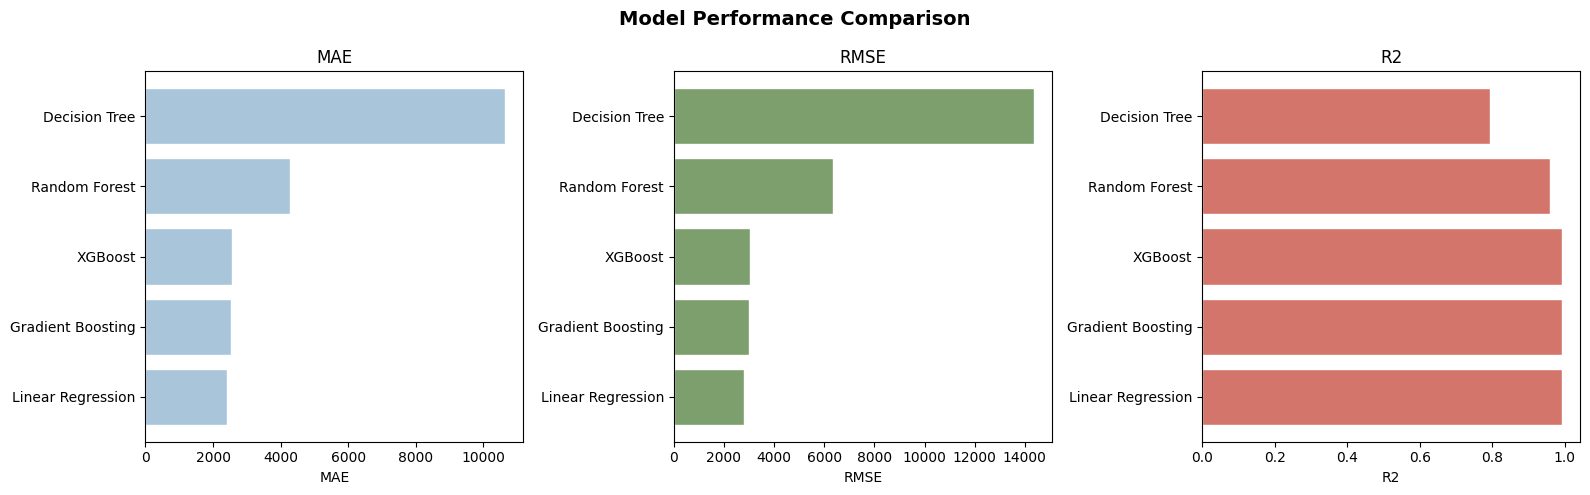

In [179]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['MAE', 'RMSE', 'R2']
colors = ['#A8C5DA', '#7D9F6E', '#D4756B']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = result_df.sort_values(metric, ascending=(metric != 'R2'))  #as higher the r2 , better the model so we are making r2 values as descending
    ax.barh(sorted_df['model'], sorted_df[metric], color=color, edgecolor='white')
    ax.set_title(metric)
    ax.set_xlabel(metric)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
  


**Conclusions**

As the linear regression model produced the least Mean Absolute Error and also has the MAE percentage of 2.13 and has the R2 score of 0.99, LinearRegression is the best model for this problem

**Plot of the linear regression model**

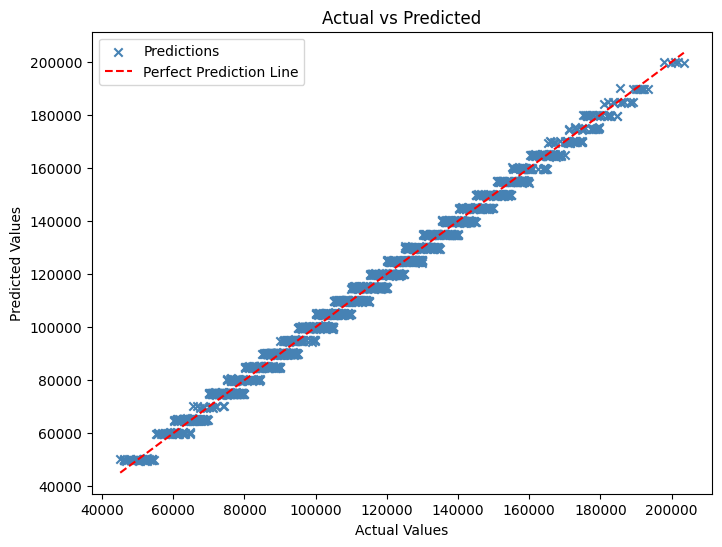

In [196]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predicted_y_test, color='steelblue',marker='x', label='Predictions')
plt.plot([y_test.min(), y_test.max()],   #this plot denotes the model that perfectly fits the target dataset
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

**Prediction Dataframe**


In [203]:
df_prediction = pd.DataFrame([{'Actual_Value':i, 'Predicted_Value':j, 'Difference':i-j} for i,j in zip(y_test,predicted_y_test)])
df_prediction.head()

,Actual_Value,Predicted_Value,Difference
0,129505,129496.634632,8.365368
1,142303,139414.949835,2888.050165
2,108995,104831.667490,4163.332510
3,123432,124919.167603,-1487.167603
4,72061,75193.097593,-3132.097593
